In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris #we are using for Machine Learning

In [7]:
#Setup & Load Data
#iris is based on flower dataset
iris = load_iris(as_frame=True)
df= iris.frame
df.colums = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target']
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df.head()

/tmp/ipykernel_7180/2830039237.py:5: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.colums = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Step 1 — Drop the label, keep only 2 features for a clean visual (1 min)

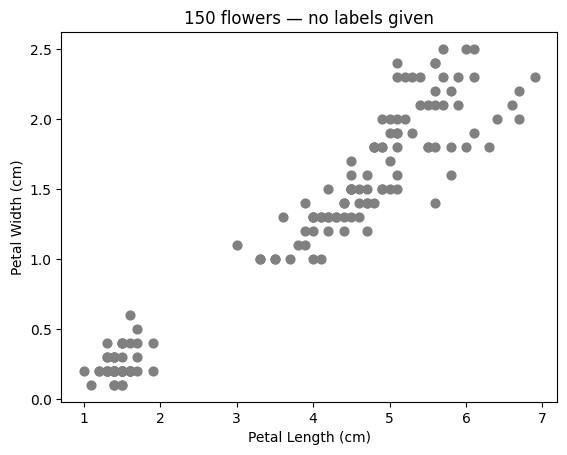

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target', 'species']


In [11]:
X = df[['petal_length', 'petal_width']].values

#Step 2 — Plot the raw, unlabeled data (1 min)
plt.scatter(X[:, 0], X[:, 1], s=40, color='gray')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('150 flowers — no labels given')
plt.show()

print(df.columns.tolist())

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target']
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

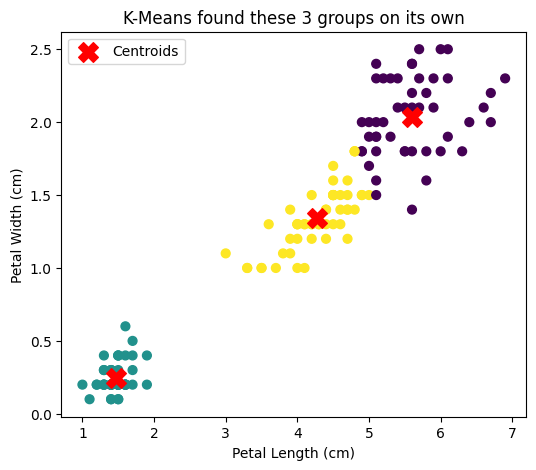

In [13]:
plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=df['cluster'], cmap='viridis', s=40)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('K-Means found these 3 groups on its own')
plt.legend()
plt.show()

In [14]:
pd.crosstab(df['species'], df['cluster'])

cluster,0,1,2
species,,,
setosa,0,50,0
versicolor,2,0,48
virginica,46,0,4


In [ ]:
"K-Means just proved these flowers naturally fall into groups. Now let's flip it: what if we DO tell the model the species during training? Same flowers, same features — but now it can learn to predict the label directly."

In [ ]:
# Demo B: Naive Bayes (Supervised)
# Step 1 — Use ALL 4 features + the real label this time (1 min)
# Step 2 — Train Gaussian Naive Bayes (1 min)
# Step 3 — Predict & evaluate (2 min)
# Step 4 — Live prediction on a new flower (2 min)
# Step 5 — See which features mattered by comparing class means (1 min)

In [15]:
from sklearn.model_selection import train_test_split

X_full = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_full = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)
# This time the label comes along for training — that's what makes it supervised.

In [16]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9111111111111111
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



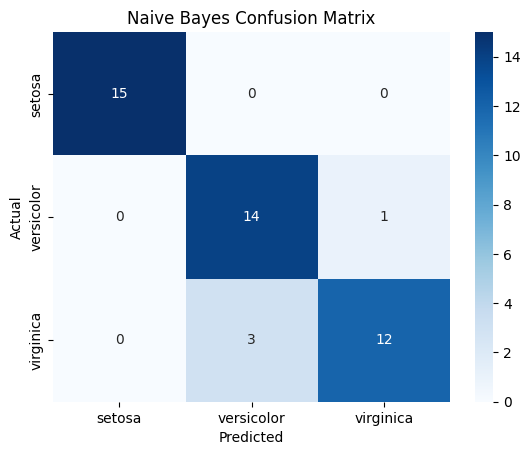

In [18]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred, labels=iris.target_names)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [19]:
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]],
    columns=['sepal_length','sepal_width','petal_length','petal_width'])
print("Predicted species:", model.predict(new_flower)[0])
print("Class probabilities:", dict(zip(model.classes_, model.predict_proba(new_flower)[0])))

Predicted species: setosa
Class probabilities: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(2.7189956824111656e-19), np.str_('virginica'): np.float64(1.901975481546108e-27)}


In [20]:
df.groupby('species')[['petal_length','petal_width']].mean()

,petal_length,petal_width
species,,
setosa,1.462,0.246
versicolor,4.260,1.326
virginica,5.552,2.026


Expected Observation
Accuracy is typically ~95–100% — noticeably higher and cleaner than K-Means' "close guess," because the model was told the correct species during training.
Confusion matrix: setosa is almost always perfect; a few versicolor/virginica may be confused with each other (their petal measurements overlap slightly) — same overlap K-Means struggled with in Demo A.
Key teaching point: Naive Bayes didn't have to discover the groups — it directly learned "these measurements → this species" from labeled examples.